In [1]:
!pip install zarr fsspec cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 46.0 MB/s eta 0:00:00


In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn

Data successfully loaded for time: 2021-12-31T23:00:00.000000000


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


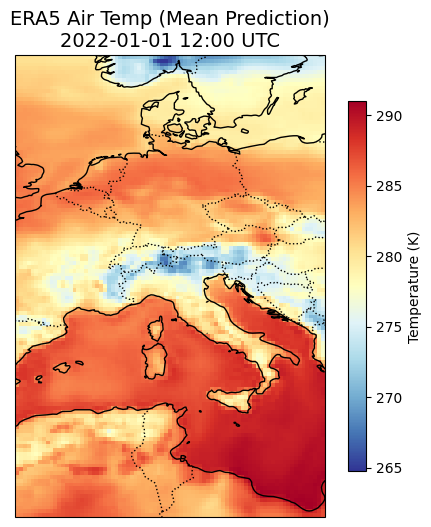

In [3]:
# 1. Connect to the Google Cloud ERA5 ARCO dataset (Zarr format)
# We use the 'ensemble_mean' and 'ensemble_spread' or the full ensemble members.
# For UQ demonstration, let's look at the ensemble spread of 2m temperature.
gcp_path = 'gs://gcp-public-data-arco-era5/ar/1959-2022-full_37-1h-0p25deg-chunk-1.zarr-v2'

# We use 'chunks={}' to open it lazily without downloading the whole PB of data
ds = xr.open_zarr(gcp_path, chunks={}, storage_options={'token': 'anon'})

time_point = ds.sel(time='2022-01-01T12:00:00', method='nearest')
subset = time_point['2m_temperature'].sel(
    latitude=slice(60, 30),
    longitude=slice(-20, 20)
).compute()

print(f"Data successfully loaded for time: {subset.time.values}")

# 3. Visualization
fig, ax = plt.subplots(1, 1, figsize=(15, 6), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot: The "Prediction" (Temperature Map)
im1 = subset.plot(ax=ax, cmap='RdYlBu_r', add_colorbar=False)

# Add geographic context
ax.set_title('ERA5 Air Temp (Mean Prediction)\n2022-01-01 12:00 UTC', fontsize=14)
ax.coastlines(resolution='50m', color='black', linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Colorbar
plt.colorbar(im1, ax=ax, label='Temperature (K)', orientation='vertical', pad=0.02, shrink=0.8)

plt.show()

In [4]:
lats, lons = np.meshgrid(subset.latitude, subset.longitude)
X = np.stack([lats.ravel(), lons.ravel()], axis=1)
y = subset.values.T.ravel()

train_mask = X[:, 1] < 15  # Longitude < 0
X_train_raw, y_train_raw = X[train_mask], y[train_mask]
X_test_raw, y_test_raw = X[~train_mask], y[~train_mask]

# Normalize using TRAIN statistics only (to avoid data leakage)
X_mean, X_std = X_train_raw.mean(axis=0), X_train_raw.std(axis=0)
y_mean, y_std = y_train_raw.mean(), y_train_raw.std()

X_train = torch.FloatTensor((X_train_raw - X_mean) / X_std)
y_train = torch.FloatTensor((y_train_raw - y_mean) / y_std).view(-1, 1)
X_test = torch.FloatTensor((X_test_raw - X_mean) / X_std)
y_test = torch.FloatTensor((y_test_raw - y_mean) / y_std).view(-1, 1)

In [5]:
dataset = TensorDataset(X_train, y_train)
loader = DataLoader(dataset, batch_size=128, shuffle=True)